<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Laboratorium nr 4: Konwolucyjne sieci neuronowe: Klasyfikacji obrazów

## Import bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Baza MNIST

- Baza MNIST zawiera zbiór trenujący składający się z 60,000 przykładów skanów ręcznie pisanych cyfr od 0 do 9 (problem klasyfikacyjny z 10 klasami).
- Zbiór testowy zawiera 10,000 przykładów.
- Każdy obraz ma rozmiar 28x28 pikseli. Stanowią one 28 * 28 = 784 wejść do sieci.
- W zagadnieniach rozpoznawania obrazów baza MNIST pełni rolę swoistego problemu `Hello world`.

#### Pobieranie bazy MNIST
- Bazę MNIST można pobrać bespośrednio ze strony http://yann.lecun.com/exdb/mnist/
- Najwygodniej jednak jest użyć bazy MNIST z wykorzystaniem biblioteki Keras

In [ ]:
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.mnist.load_data()
)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
train_images = np.expand_dims(train_images, axis=-1) / 255.0
train_labels = np.int64(train_labels)
test_images = np.expand_dims(test_images, axis=-1) / 255.0
test_labels = np.int64(test_labels)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


Przykładowe cyfry:

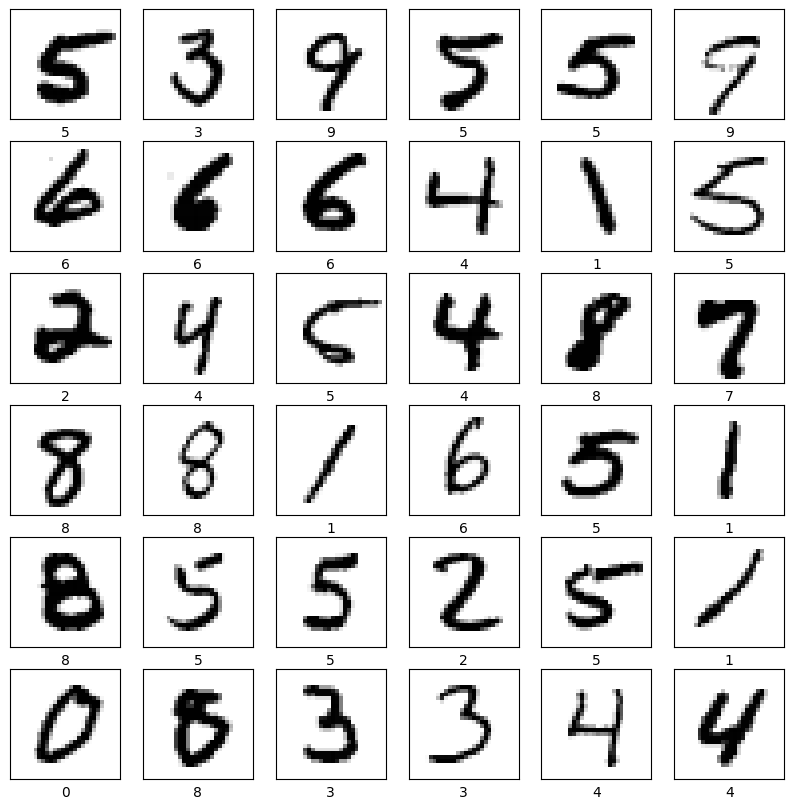

In [ ]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

## Sieć wielowarstwowa

### Tworzenie modelu

#### Ćwiczenie 1:
Sieć pełnych połączeń
- Stwórz w bibliotece keras model klasycznej sieci wielowarstwowej z dwiema warstwami ukrytymi.
- Dla pierwszej warstwy ustaw liczbę 128 neuronów
- Dla drugie warstwy liczbę neuronów odpowiedającą liczbie klas.
- Dobierz odpowiednie funkcje aktywacji.

In [7]:
import tensorflow as tf
import tensorflow.keras as keras
from keras.metrics import mean_absolute_error, mean_absolute_percentage_error
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Input

In [ ]:
def fc_model():
    x = Input(shape=(28, 28, 1))
    xf = Flatten()(x)
    # TODO:
    h = Dense(128, activation="relu")(xf)  # dodaj pierwszą warstwę ukrytą
    h = Dense(128, activation="relu")(h)  # dodaj drugą warstwę ukrytą
    y = Dense(10, activation="softmax")(h)
    return Model(inputs=x, outputs=y)


model = fc_model()
model.summary()

I0000 00:00:1773221162.367247   14198 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:02:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

### Kompilacja

#### Ćwiczenie 2:
Skompiluj model ustawiając:
- funkcje straty: `sparse_categorical_crossentropy`
- algorytm optymalizacji: np. `SGD`
- metryki monitorujące proces uczenia: `accuracy`

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

### Trenowanie
Trenowanie z wykorzystaniem podziału na dane uczące i walidacyjne, oraz `ModelCheckpoint`, czylu zapisywanie najlepszego modelu

In [12]:
from keras.callbacks import ModelCheckpoint

In [ ]:
# aby zapisać model na Google Drive podaj odpowiednią ścieżkę
cb = [
    ModelCheckpoint("model_fc_mnist.keras", monitor="val_accuracy", save_best_only=True)
]

In [14]:
BATCH_SIZE = 64
EPOCHS = 20

In [ ]:
model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=cb,
)

Epoch 1/20


2026-03-11 10:26:12.393609: I external/local_xla/xla/service/service.cc:163] XLA service 0x78b248004a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 10:26:12.393638: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2026-03-11 10:26:12.430732: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 10:26:12.547601: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-11 10:26:12.583384: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-11 10:26:12.583449: I e

 77/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5869 - loss: 1.3901

I0000 00:00:1773221174.821355   15777 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


332/750 ━━━━━━━━━━━━━━━━━━━━ 56s 135ms/step - accuracy: 0.7787 - loss: 0.7583

2026-03-11 10:26:16.576921: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-11 10:26:16.732703: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43', 20 bytes spill stores, 20 bytes spill loads

2026-03-11 10:26:16.946081: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_36', 100 bytes spill stores, 100 bytes spill loads

2026-03-11 10:26:16.999931: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_36', 48 bytes 

750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9136 - loss: 0.2928 - val_accuracy: 0.9588 - val_loss: 0.1444
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9655 - loss: 0.1168 - val_accuracy: 0.9687 - val_loss: 0.1098
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9748 - loss: 0.0812 - val_accuracy: 0.9700 - val_loss: 0.0932
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9813 - loss: 0.0600 - val_accuracy: 0.9740 - val_loss: 0.0871
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9850 - loss: 0.0463 - val_accuracy: 0.9703 - val_loss: 0.0976
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0357 - val_accuracy: 0.9708 - val_loss: 0.1084
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9910 - loss: 0.0290 - val_accuracy: 0.9727 - val_loss: 0.1002
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9923 - loss: 0.0245 - val_accuracy: 0.9724 - val_

### Ewaluacja zbioru testowego

In [16]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.1466   


[0.14657476544380188, 0.9760000109672546]

Model z pliku

In [17]:
from keras.models import load_model

In [ ]:
fmodel = load_model("model_fc_mnist.keras")
fmodel.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9781 - loss: 0.1029


[0.1029379665851593, 0.9781000018119812]

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


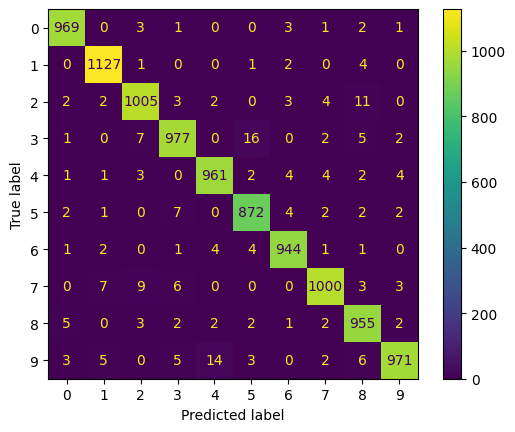

In [20]:
predictions = fmodel.predict(test_images)
predictions = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Najlepsze wyniki dla bazy MNIST
http://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#4d4e495354

## Sieć konwolucyjna

### Prosty model

#### Ćwiczenie 3:

- Stwórz w bibliotece keras model prostej sieci konwolucyjnej z 1 warstwą conwolucyjną, 1 warstwą MaxPooling i warstwami klasyfikacyjnymi jak w poprzednim modelu.

In [21]:
from keras.layers import Conv2D, MaxPool2D, Dropout

In [ ]:
def conv_model():
    x = Input(shape=(28, 28, 1))
    conv = Conv2D(128, kernel_size=3, activation="relu")(
        x
    )  # dodaj warstwę konwolucyjną
    pool = MaxPool2D(pool_size=2)(conv)  # dodaj warstwę max pooling
    flat = Flatten()(pool)
    h = Dense(128, activation="relu")(flat)
    # h = Dense(128, activation='relu')(h)
    y = Dense(10, activation="softmax")(h)
    return Model(inputs=x, outputs=y)


model = conv_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,594 (10.57 MB)

 Trainable params: 2,771,594 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

### Kompilacja i trenowanie

#### Ćwiczenie 4:
- Skompiluj i wytrenuj model ustawiając parametry jak przy sieci wielowarstwowej.

In [ ]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
cb = [
    ModelCheckpoint(
        "model_conv_mnist.keras", monitor="val_accuracy", save_best_only=True
    )
]

In [ ]:
model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=cb,
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9478 - loss: 0.1702 - val_accuracy: 0.9755 - val_loss: 0.0786
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0550 - val_accuracy: 0.9816 - val_loss: 0.0596
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0334 - val_accuracy: 0.9838 - val_loss: 0.0523
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9851 - val_loss: 0.0546
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.9855 - val_loss: 0.0518
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9845 - val_loss: 0.0583
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9826 - val_loss: 0.0774
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9974 - loss: 0.0078 - val_accuracy: 0.

### Ewaluacja zbioru testowego

In [26]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9859 - loss: 0.0793 


[0.07930298894643784, 0.9858999848365784]

Model z pliku

In [ ]:
fmodel = load_model("model_conv_mnist.keras")
fmodel.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9863 - loss: 0.0555


[0.0554984025657177, 0.986299991607666]

## Ćwiczenie 5:
Zdefiniuj, wytrenuj i przetestuj model sieci konwolucyjnej jak na rysunku:
![convnet](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/cw5.PNG)

In [ ]:
def conv_model():
    x = Input(shape=(28, 28, 1))
    conv = Conv2D(24, kernel_size=3, activation="relu")(x)  # dodaj warstwę konwolucyjną
    pool = MaxPool2D(pool_size=2)(conv)
    conv = Conv2D(36, kernel_size=3, activation="relu")(pool)
    pool = MaxPool2D(pool_size=2)(conv)
    flat = Flatten()(pool)
    h = Dense(128, activation="relu")(flat)
    # h = Dense(128, activation='relu')(h)
    y = Dense(10, activation="softmax")(h)
    return Model(inputs=x, outputs=y)


model = conv_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 36)     │         7,812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,670 (486.99 KB)

 Trainable params: 124,670 (486.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
cb = [
    ModelCheckpoint(
        "model_conv2_mnist.keras", monitor="val_accuracy", save_best_only=True
    )
]

In [ ]:
model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_split=0.2,
    callbacks=cb,
)

Epoch 1/20


2026-03-11 10:44:55.967749: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-11 10:44:56.259008: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_460', 8 bytes spill stores, 8 bytes spill loads

2026-03-11 10:44:56.294367: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_460', 4 bytes spill stores, 4 bytes spill loads

2026-03-11 10:44:56.457916: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_460', 420 bytes sp

750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9389 - loss: 0.2058 - val_accuracy: 0.9774 - val_loss: 0.0744
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9811 - loss: 0.0600 - val_accuracy: 0.9827 - val_loss: 0.0557
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9854 - val_loss: 0.0553
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9899 - loss: 0.0311 - val_accuracy: 0.9859 - val_loss: 0.0480
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0242 - val_accuracy: 0.9803 - val_loss: 0.0672
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy: 0.9879 - val_loss: 0.0414
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9951 - loss: 0.0149 - val_accuracy: 0.9877 - val_loss: 0.0474
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9961 - loss: 0.0116 - val_accuracy: 0.9892 - val_

In [ ]:
fmodel = load_model("model_conv2_mnist.keras")
fmodel.evaluate(test_images, test_labels)

306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9892 - loss: 0.0436

2026-03-11 10:43:39.947766: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9924 - loss: 0.0329


[0.03290043771266937, 0.9923999905586243]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


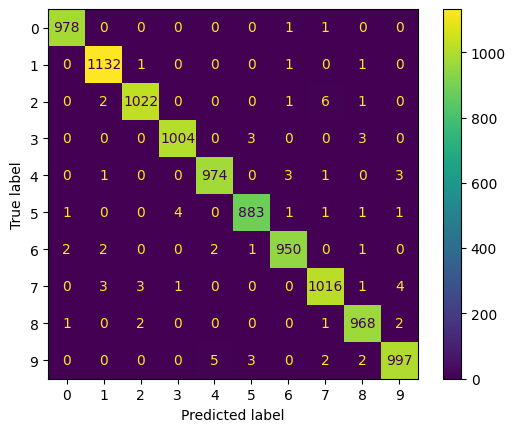

In [40]:
predictions = fmodel.predict(test_images)
predictions = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Wizualizacja Predykcji
Za pomocą poniższych funkcji zwizualizuj wyniki predykcj modelu z ćwiczenia 5 na zbiorze testowym.

In [ ]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(np.squeeze(img), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel(
        "{} {:2.0f}% ({})".format(
            predicted_label, 100 * np.max(predictions_array), true_label
        ),
        color=color,
    )


def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color("red")
    thisplot[true_label].set_color("blue")

In [42]:
predictions = fmodel.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


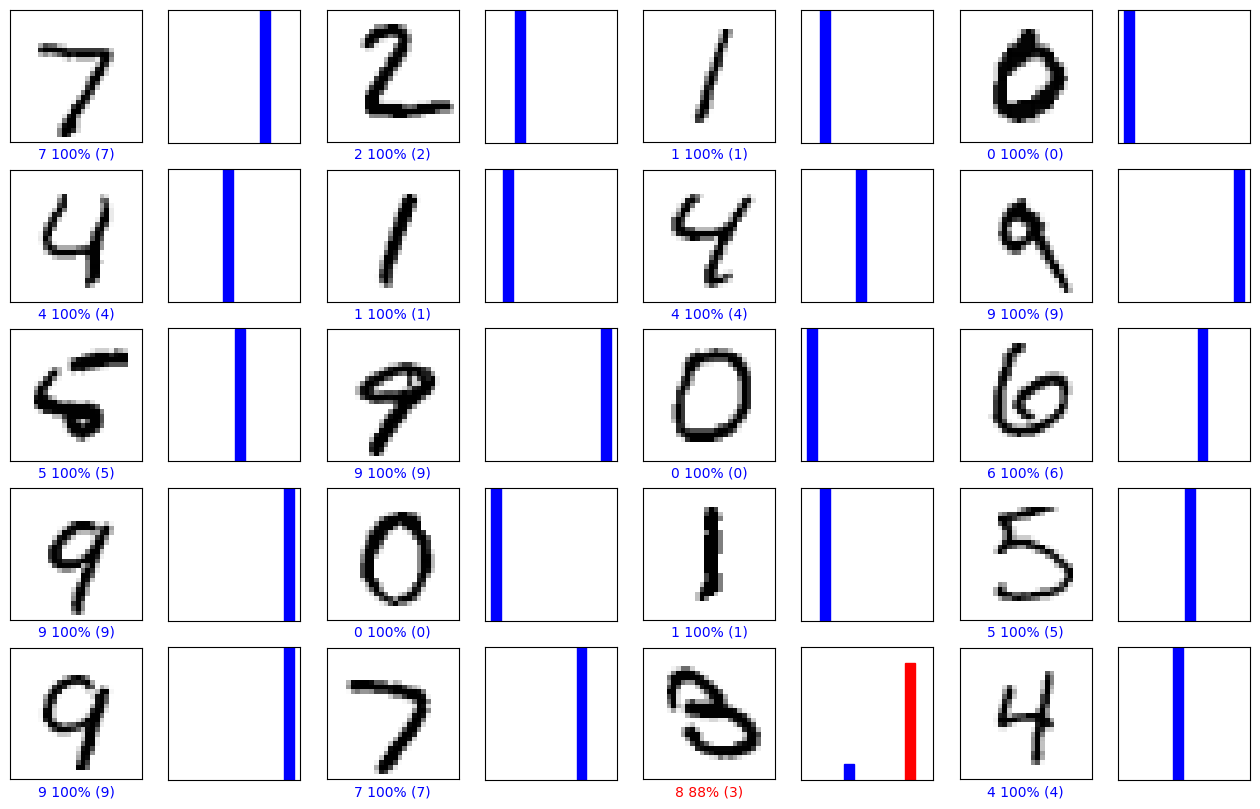

In [ ]:
num_rows = 5
num_cols = 4
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

## Wizualizacja filtrów i map cech
Zwizualizuj filtry w pierwszej warstwie konwolucyjnej oraz mapy cech powstałe po pierwszej warstwie konwolucyjnej

In [48]:
fmodel.layers

[<InputLayer name=input_layer_3, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_3, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Flatten name=flatten_2, built=True>,
 <Dense name=dense_5, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>]

In [58]:
wc1 = fmodel.layers[1]
wc1 = wc1.get_weights()[0]

In [59]:
wc1.shape

(3, 3, 1, 24)

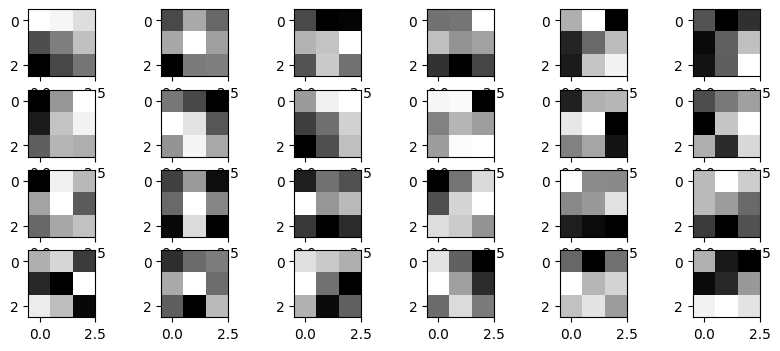

In [ ]:
# show first 24 filters from wc1 in a 4x6 grid
fig, ax = plt.subplots(4, 6, figsize=(10, 4))
ax = ax.flatten()

for i in range(24):
    ax[i].imshow(wc1[:, :, 0, i], cmap="gray")
    # ax[i].axis('off')

# plt.tight_layout()
plt.show()

In [ ]:
mcl = Model(inputs=fmodel.input, outputs=fmodel.layers[1].output)

In [71]:
img = test_images[12:13]

In [72]:
fm = mcl.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


In [73]:
fm.shape

(1, 26, 26, 24)

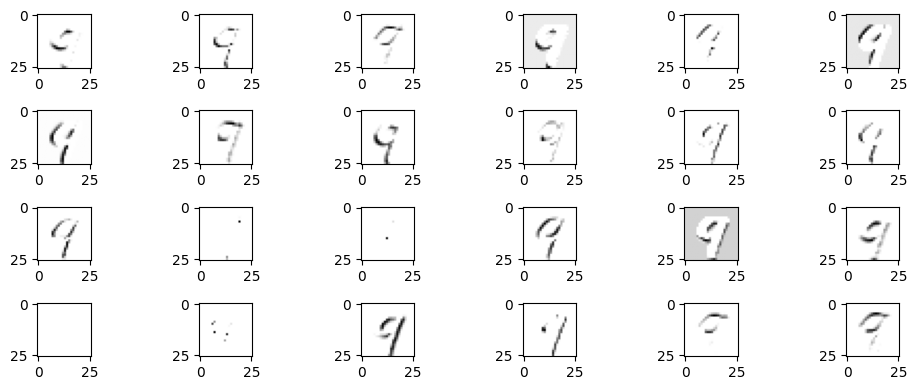

In [80]:
# show first 24 filters from wc1 in a 4x6 grid
fig, ax = plt.subplots(4, 6, figsize=(10, 4))
ax = ax.flatten()

for i in range(24):
    ax[i].imshow(fm[0, :, :, i], cmap=plt.cm.binary)
    # ax[i].axis('off')

plt.tight_layout()
plt.show()